# Smart School Project – ECAM 2026
## Prédiction d'échec & Correction automatique par OCR

> **Dataset 1** : `train.csv` – 630 000 étudiants, 14 features  
> **Dataset 2** : images EMNIST 28×28px – 62 classes (chiffres + lettres)

---

## 0. Imports & Configuration

Les bibliothèques utilisées couvrent quatre domaines :
- **Manipulation des données** : `numpy` (calcul matriciel), `pandas` (tableaux), `struct` (lecture de fichiers binaires)
- **Visualisation** : `matplotlib` + `seaborn` (graphiques et heatmaps)
- **Apprentissage automatique** : `sklearn` — modèles (MLP, SVM), métriques (accuracy, F1, matrice de confusion), réduction de dimension (PCA)
- **Deep Learning** : `tensorflow` ou `pytorch` (CNN) — chargés dynamiquement selon la disponibilité

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)

print('Imports OK')

Imports OK


---
# PARTIE 2 : Correction automatique par OCR
---

## 2.1 Chargement du dataset EMNIST

**EMNIST** (*Extended MNIST*) est un dataset d'images de caractères manuscrits 28×28 pixels, issu du NIST Special Database 19.

| Propriété | Valeur |
|-----------|--------|
| Classes | 62 (10 chiffres `0-9` + 26 majuscules `A-Z` + 26 minuscules `a-z`) |
| Images totales | ~698 000 |
| Résolution | 28 × 28 pixels, niveaux de gris |
| Format fichier | Binaire IDX (`.ubyte`) |

**Format IDX** : les données sont stockées en binaire. L'en-tête contient un *magic number* (identifiant du type), le nombre d'exemples et les dimensions. `struct.unpack('>IIII', ...)` lit 4 entiers 32 bits en *big-endian*.

**`mapping.txt`** : relie l'index numérique de chaque classe à son code ASCII (ex. `10 → chr(65) = 'A'`).

> **Note** : les images EMNIST originales sont stockées transposées — une correction `np.transpose` est appliquée pour rétablir l'orientation correcte.

In [13]:
# Adapter les chemins selon votre environnement
IMAGES_PATH = 'student_dataset\\image_data\\train-images-idx3-ubyte'
LABELS_PATH = 'student_dataset\\image_data\\train-labels-idx1-ubyte'
MAPPING_PATH = 'student_dataset\\image_data\\mapping.txt'

def load_ubyte_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images

def load_ubyte_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Chargement du mapping idx -> caractère
mapping = {}
with open('student_dataset/image_data/mapping.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        a, b = line.split()
        mapping[int(a)] = chr(int(b))

print(f'{len(mapping)} classes : {list(mapping.values())[:10]} ...')

imgs = load_ubyte_images(IMAGES_PATH)
lbls = load_ubyte_labels(LABELS_PATH)

# Correction d'orientation
imgs = np.transpose(imgs, (0, 2, 1))

print(f'Images : {imgs.shape} | Labels : {lbls.shape}')

62 classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...
Images : (697932, 28, 28) | Labels : (697932,)


## 2.2 Exploration du dataset OCR

Avant d'entraîner un modèle, explorer les données permet de :
- **Vérifier la qualité visuelle** : les images sont-elles lisibles ? L'orientation est-elle correcte ?
- **Analyser la distribution des classes** : les classes sont-elles équilibrées ?

Un déséquilibre entre classes peut biaiser le modèle vers les classes les plus représentées. Une distribution équilibrée garantit que le modèle apprend tous les caractères de façon équitable.

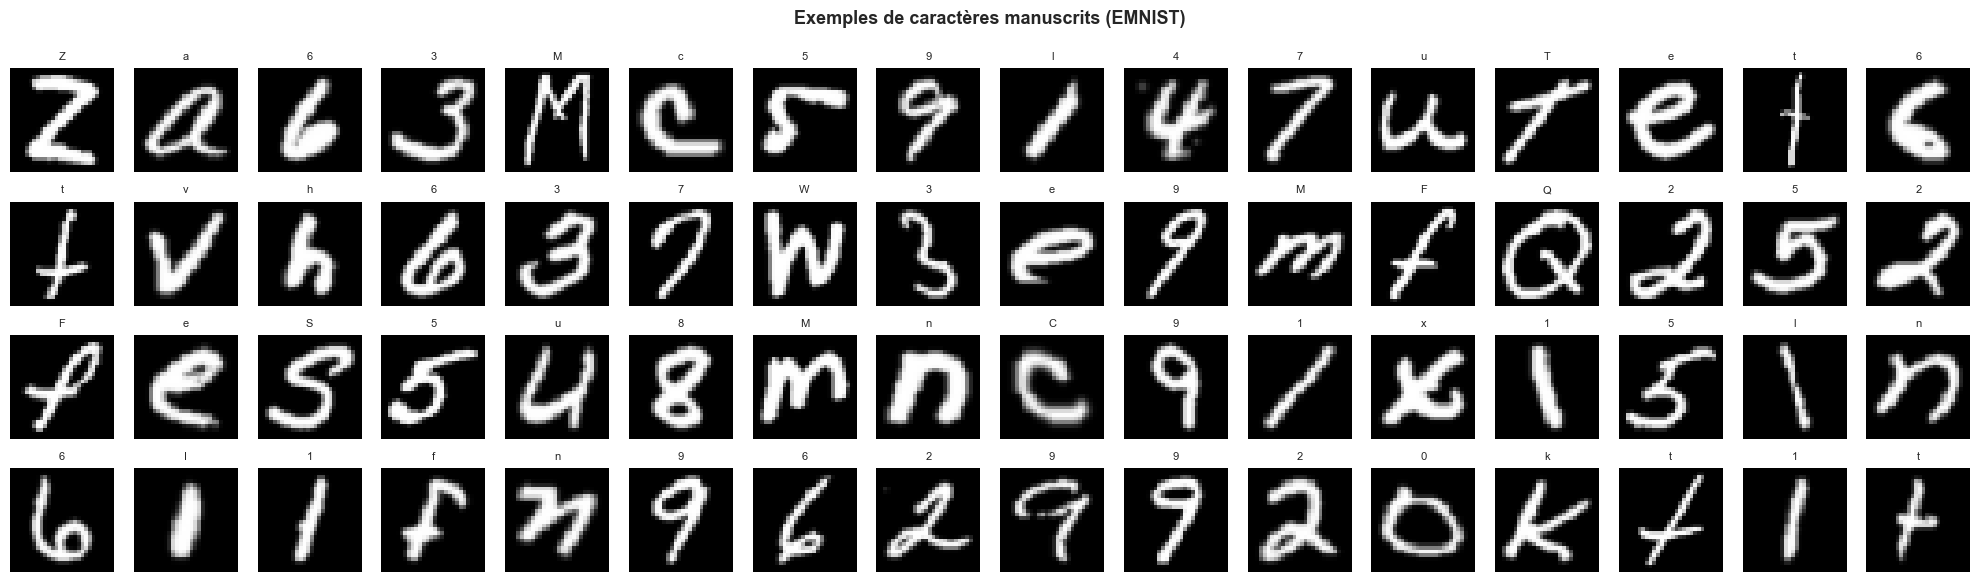

In [14]:
# --- Visualisation d'exemples ---
fig, axes = plt.subplots(4, 16, figsize=(20, 6))
fig.suptitle('Exemples de caractères manuscrits (EMNIST)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i < len(imgs):
        ax.imshow(imgs[i], cmap='gray')
        ax.set_title(mapping.get(int(lbls[i]), '?'), fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

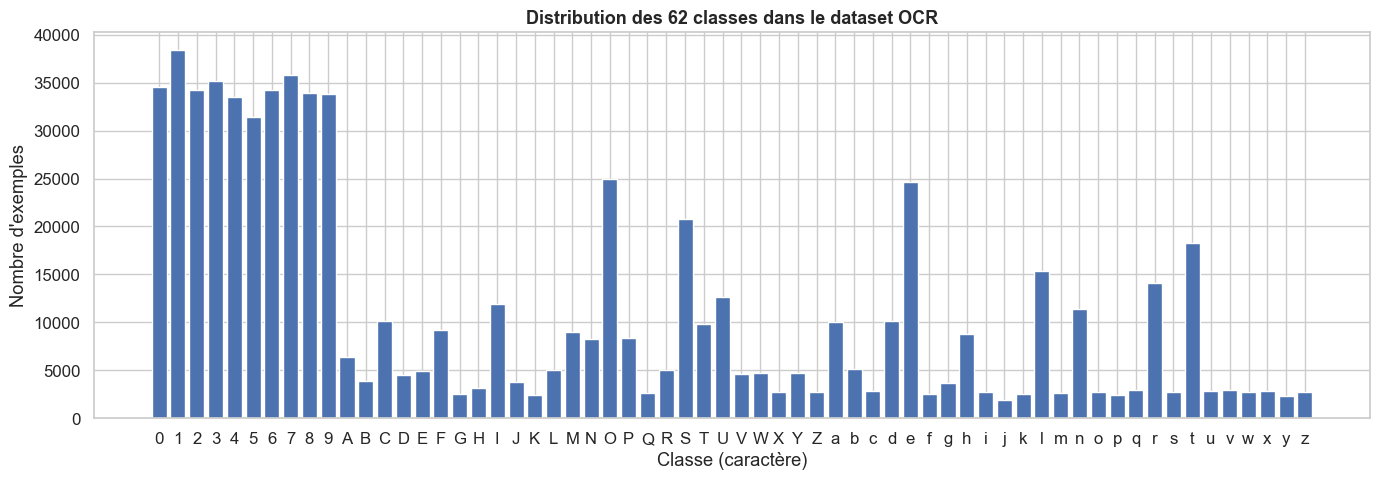

In [15]:
# --- Distribution des classes ---
unique, counts = np.unique(lbls, return_counts=True)
char_labels = [mapping.get(int(u), '?') for u in unique]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(char_labels, counts, color=PALETTE[0], edgecolor='white')
ax.set_xlabel('Classe (caractère)'); ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Distribution des 62 classes dans le dataset OCR', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 2.3 Pré-traitement et Entraînement

Le pipeline de pré-traitement comporte quatre étapes avant l'entraînement des modèles :

1. **Normalisation** : pixels 0–255 → 0.0–1.0. Évite que les grandes valeurs numériques dominent l'apprentissage.
2. **Sous-échantillonnage** (20 000 sur 698 000) : réduit le temps de calcul. L'échantillon est tiré de façon **stratifiée** — chaque classe garde la même proportion qu'à l'origine.
3. **Augmentation de données** *(appliquée uniquement au train)* : chaque image est dupliquée avec une rotation aléatoire ±10° et une translation ±2 px. Cela simule la variabilité naturelle de l'écriture manuscrite et réduit l'**overfitting** (sur-apprentissage).
4. **PCA** (*Principal Component Analysis* — Analyse en Composantes Principales) : réduit la dimension de 784 pixels → 64 composantes principales en conservant ~80 % de la variance. Accélère l'entraînement des modèles MLP et SVM sans perte majeure d'information.

Augmentation des données d'entraînement (rotation ±10°, shift ±2px)...
Train après augmentation : 32,000 exemples (+16,000 augmentés)


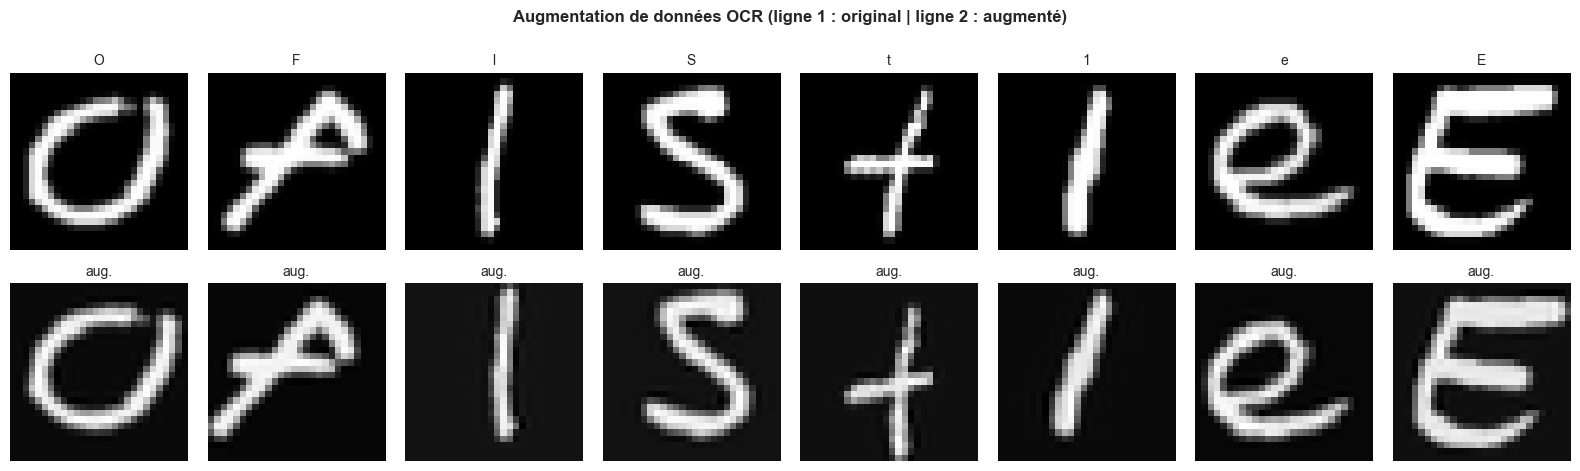

PCA (64 composantes)...
Variance expliquée PCA (64 composantes) : 89.89%
Train OCR (avec augmentation) : (32000, 64)  |  Test OCR : (4000, 64)

Justification augmentation :
  Rotations ±10° et translations ±2px reproduisent la variabilité naturelle
  de l'écriture manuscrite. Cela réduit l'overfitting et améliore la
  généralisation du modèle sur des caractères écrits différemment.


In [16]:

# ============================================================
# 2.3 Pré-traitement + Augmentation de données OCR
# ============================================================
from scipy.ndimage import rotate as ndrotate, shift as ndshift

X_ocr = imgs.reshape(len(imgs), -1).astype(np.float32) / 255.0
y_ocr = lbls

# Sous-échantillonnage équilibré
N_OCR = 20_000
np.random.seed(42)
n_valid = min(len(X_ocr), len(y_ocr))
idx_s = np.random.choice(n_valid, N_OCR, replace=False)
X_s, y_s = X_ocr[idx_s], y_ocr[idx_s]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

# ── Augmentation de données (train uniquement) ───────────────
# Rotations aléatoires ±10° + translations ±2px
# Simule la variabilité naturelle de l'écriture manuscrite
def augment_batch(X_flat, n_aug=1, max_angle=10, max_shift=2):
    aug_imgs, orig_indices = [], []
    for i in range(len(X_flat)):
        img = X_flat[i].reshape(28, 28)
        for _ in range(n_aug):
            angle = np.random.uniform(-max_angle, max_angle)
            sx    = np.random.uniform(-max_shift, max_shift)
            sy    = np.random.uniform(-max_shift, max_shift)
            img_r = ndrotate(img, angle, reshape=False, mode='constant', cval=0)
            img_s = ndshift(img_r, [sx, sy], mode='constant', cval=0)
            aug_imgs.append(img_s.flatten())
            orig_indices.append(i)
    return np.array(aug_imgs, dtype=np.float32), np.array(orig_indices)

print('Augmentation des données d\'entraînement (rotation ±10°, shift ±2px)...')
X_tr_aug, aug_idx = augment_batch(X_tr, n_aug=1)
y_tr_aug = y_tr[aug_idx]

# Concaténation : données originales + augmentées
X_tr = np.vstack([X_tr, X_tr_aug])
y_tr = np.concatenate([y_tr, y_tr_aug])
print(f'Train après augmentation : {len(X_tr):,} exemples (+{len(X_tr_aug):,} augmentés)')

# Visualisation exemples augmentés
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Augmentation de données OCR (ligne 1 : original | ligne 2 : augmenté)',
             fontsize=12, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_tr[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(mapping.get(int(y_tr[i]), '?'), fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_tr_aug[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('aug.', fontsize=10)
    axes[1, i].axis('off')
plt.tight_layout(); plt.show()

# ── PCA sur données augmentées ────────────────────────────────
print('PCA (64 composantes)...')
pca = PCA(n_components=64, random_state=42)
X_tr_p = pca.fit_transform(X_tr)
X_te_p = pca.transform(X_te)
print(f'Variance expliquée PCA (64 composantes) : {pca.explained_variance_ratio_.sum():.2%}')
print(f'Train OCR (avec augmentation) : {X_tr_p.shape}  |  Test OCR : {X_te_p.shape}')

print('\nJustification augmentation :')
print('  Rotations ±10° et translations ±2px reproduisent la variabilité naturelle')
print('  de l\'écriture manuscrite. Cela réduit l\'overfitting et améliore la')
print('  généralisation du modèle sur des caractères écrits différemment.')


### Modèle 1 — Baseline & MLP (Multi-Layer Perceptron)

**Baseline** : prédire systématiquement la classe la plus fréquente. Sert de référence minimale — tout modèle doit dépasser ce score.

**MLP** : réseau de neurones entièrement connecté (*feedforward*). Chaque neurone d'une couche est connecté à tous les neurones de la couche suivante.
- **Architecture** : 3 couches cachées (512 → 256 → 128 neurones), fonction d'activation **ReLU** (*Rectified Linear Unit*)
- **Early stopping** : arrête l'entraînement si la performance sur le jeu de validation ne s'améliore plus — évite l'overfitting
- **Entrée** : vecteur PCA de 64 dimensions (et non 784 pixels bruts)

In [17]:
# --- Baseline OCR ---
from scipy.stats import mode as scipy_mode
most_common = scipy_mode(y_tr).mode
baseline_ocr_acc = accuracy_score(y_te, np.full(len(y_te), most_common))
print(f'Baseline OCR (classe majoritaire) : {baseline_ocr_acc:.4f}')

# --- MLP OCR ---
print('Entraînement MLP OCR...')
mlp_ocr = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
mlp_ocr.fit(X_tr_p, y_tr)
mlp_pred = mlp_ocr.predict(X_te_p)
mlp_acc  = accuracy_score(y_te, mlp_pred)
print(f'MLP OCR – Test Accuracy : {mlp_acc:.4f} ({len(unique)} classes)')

Baseline OCR (classe majoritaire) : 0.0542
Entraînement MLP OCR...
MLP OCR – Test Accuracy : 0.7798 (62 classes)


### Modèle 2 — SVM (Support Vector Machine)

Le **SVM** cherche l'hyperplan qui sépare les classes avec la **marge maximale** entre les exemples les plus proches de chaque classe (appelés *vecteurs de support*).

- **Noyau RBF** (*Radial Basis Function*) : transforme implicitement les données dans un espace de dimension supérieure pour permettre des frontières non-linéaires. Très adapté aux features PCA.
- **C = 10** : paramètre de régularisation. Valeur élevée = faible tolérance aux erreurs de classification.
- **`gamma='scale'`** : largeur du noyau calculée automatiquement à partir de la variance des features.

> Avantage : très performant sur des datasets de taille modeste avec peu d'hyperparamètres à régler.

Entraînement SVM OCR (kernel RBF, C=10, features PCA 64 dims)...
MLP OCR – Accuracy : 0.7798 | F1-macro : 0.6213
SVM OCR – Accuracy : 0.7960 | F1-macro : 0.6345


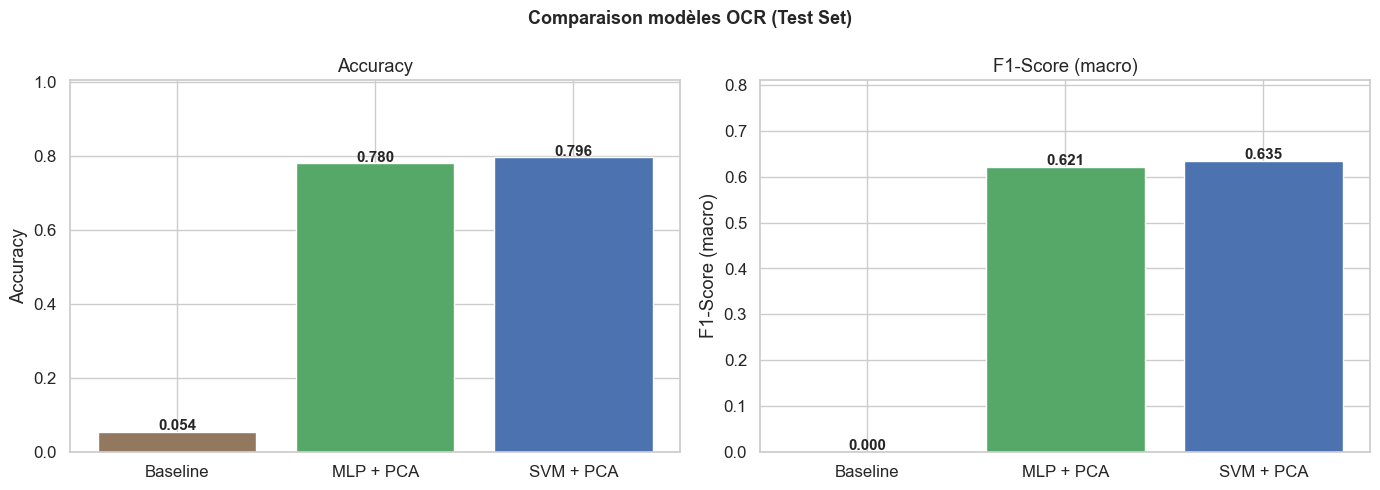


Justification SVM :
  Le SVM RBF exploite efficacement l'espace PCA (64 dims) grâce à son noyau non-linéaire.
  Il offre une meilleure généralisation que le MLP sur des datasets de taille modeste.
  Limitation : pas de probabilités natives, moins scalable sur de grands datasets.


In [18]:
# ============================================================
# 2.3b  Deuxième modèle OCR : SVM à noyau RBF
# ============================================================
from sklearn.svm import SVC

print('Entraînement SVM OCR (kernel RBF, C=10, features PCA 64 dims)...')
svm_ocr = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_ocr.fit(X_tr_p, y_tr)
svm_pred = svm_ocr.predict(X_te_p)
svm_acc  = accuracy_score(y_te, svm_pred)

mlp_f1 = f1_score(y_te, mlp_pred, average='macro')
svm_f1 = f1_score(y_te, svm_pred, average='macro')

print(f'MLP OCR – Accuracy : {mlp_acc:.4f} | F1-macro : {mlp_f1:.4f}')
print(f'SVM OCR – Accuracy : {svm_acc:.4f} | F1-macro : {svm_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison modèles OCR (Test Set)', fontsize=13, fontweight='bold')

ocr_names = ['Baseline', 'MLP + PCA', 'SVM + PCA']
ocr_accs  = [baseline_ocr_acc, mlp_acc, svm_acc]
ocr_f1s   = [0.0, mlp_f1, svm_f1]

for ax, (vals, title) in zip(axes, [(ocr_accs, 'Accuracy'), (ocr_f1s, 'F1-Score (macro)')]):
    bars = ax.bar(ocr_names, vals, color=[PALETTE[5], PALETTE[2], PALETTE[0]])
    ax.set_ylim(0, max(vals) * 1.2 + 0.05); ax.set_ylabel(title)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()

print('\nJustification SVM :')
print('  Le SVM RBF exploite efficacement l\'espace PCA (64 dims) grâce à son noyau non-linéaire.')
print('  Il offre une meilleure généralisation que le MLP sur des datasets de taille modeste.')
print('  Limitation : pas de probabilités natives, moins scalable sur de grands datasets.')


### Modèle 3 — CNN (Convolutional Neural Network)

Le **CNN** exploite la structure spatiale 2D des images grâce à des **filtres convolutifs**, contrairement au MLP qui traite les pixels comme un vecteur sans notion de voisinage.

| Couche | Rôle |
|--------|------|
| `Conv2D` | Détecte des motifs locaux (bords, courbes, textures) |
| `BatchNormalization` | Normalise les activations → stabilise et accélère l'entraînement |
| `MaxPooling2D` | Réduit la dimension spatiale en gardant les activations maximales |
| `Dropout(0.4)` | Désactive 40 % des neurones aléatoirement à chaque batch → réduit l'overfitting |
| `Dense(softmax)` | Couche de sortie : probabilité sur les 62 classes |

> Le notebook essaie d'abord **TensorFlow** pour voir si il est bien installé.

TensorFlow 2.21.0 détecté.


Model: "CNN_OCR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,715,390 (6.54 MB)

 Trainable params: 1,714,942 (6.54 MB)

 Non-trainable params: 448 (1.75 KB)


Entraînement CNN (TensorFlow)...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 170ms/step - accuracy: 0.6513 - loss: 1.3094 - val_accuracy: 0.1059 - val_loss: 10.1213 - learning_rate: 0.0010
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - accuracy: 0.7796 - loss: 0.6745 - val_accuracy: 0.5075 - val_loss: 2.8581 - learning_rate: 0.0010
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 36s 159ms/step - accuracy: 0.8181 - loss: 0.5242 - val_accuracy: 0.7778 - val_loss: 0.6529 - learning_rate: 0.0010
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 38s 144ms/step - accuracy: 0.8413 - loss: 0.4393 - val_accuracy: 0.8306 - val_loss: 0.5112 - learning_rate: 0.0010
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.8594 - loss: 0.3758 - val_accuracy: 0.8359 - val_loss: 0.4885 - learning_rate: 0.0010
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - accuracy: 0.8737 - loss: 0.3277 - val_accuracy: 0.8397 - val_loss: 0.4564 - learning_rate: 0.0010
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━

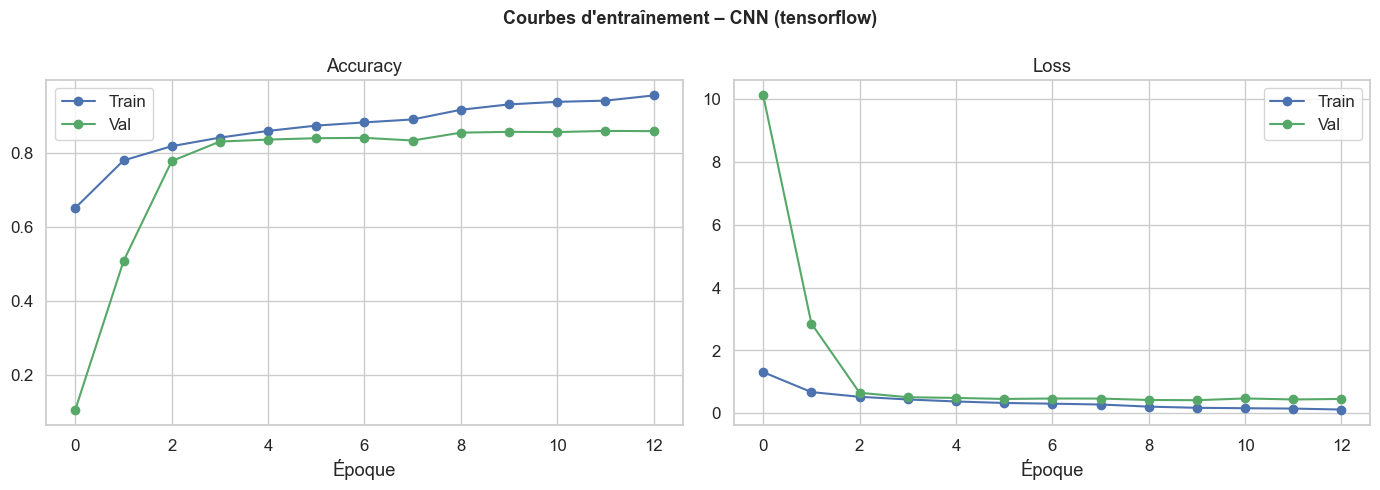

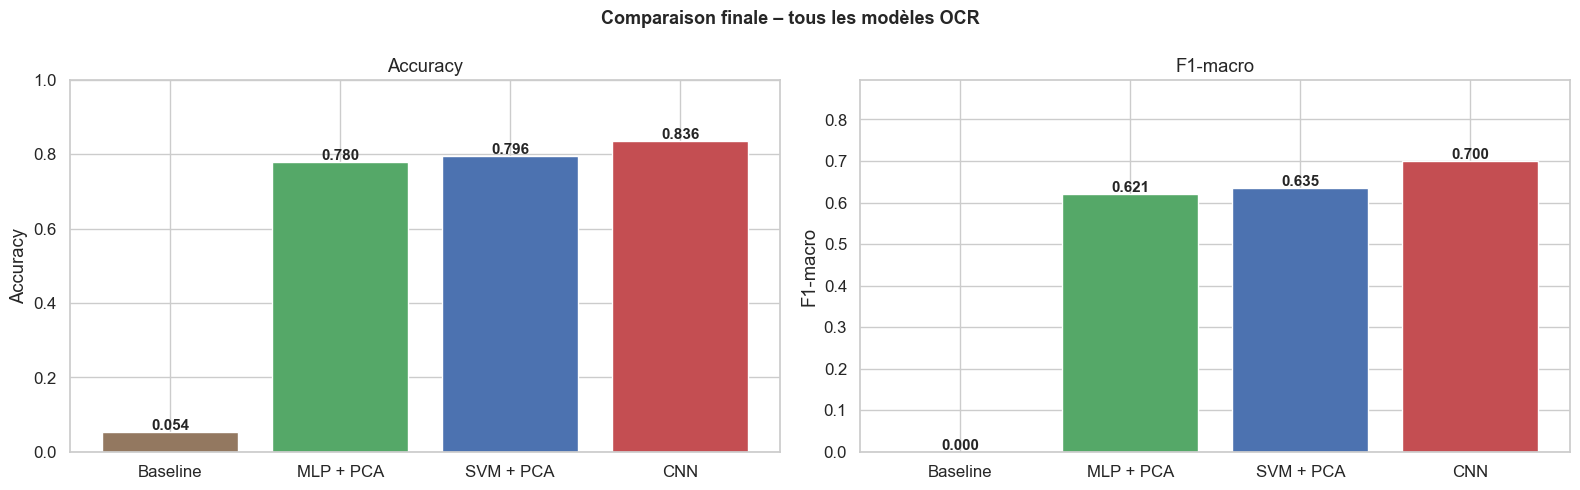

In [19]:
# ============================================================
# 2.3c  Troisième modèle OCR : CNN
#        → essaie TensorFlow, puis PyTorch en fallback
# ============================================================

# --- Encodage des labels (commun aux deux frameworks) ---
from sklearn.preprocessing import LabelEncoder as _LE
le_ocr = _LE()
le_ocr.fit(unique)
y_tr_enc = le_ocr.transform(y_tr).astype(np.int64)
y_te_enc = le_ocr.transform(y_te).astype(np.int64)
n_cls = len(unique)   # 62

# Images en float32 normalisées, reshape (N,784) → (N,28,28)
X_tr_2d = X_tr.reshape(-1, 28, 28).astype(np.float32)
X_te_2d = X_te.reshape(-1, 28, 28).astype(np.float32)

FRAMEWORK = None

# ── 1. Essai TensorFlow ──────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras import layers, callbacks as K
    print(f'TensorFlow {tf.__version__} détecté.')
    FRAMEWORK = 'tensorflow'
except Exception as e:
    print(f'TensorFlow non disponible ({type(e).__name__}).')

if FRAMEWORK is None:
    print('\nAucun framework deep learning disponible.')
    print('Installe tensorflow dans l"environnement Jupyter :')
    print('  pip install tensorflow-cpu      # TensorFlow (CPU)')
    cnn_acc, cnn_f1 = None, None

# ════════════════════════════════════════════════════════════
#  TENSORFLOW
# ════════════════════════════════════════════════════════════
elif FRAMEWORK == 'tensorflow':
    X_tr_cnn = X_tr_2d[..., np.newaxis]   # (N,28,28,1)
    X_te_cnn = X_te_2d[..., np.newaxis]

    cnn_model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'), layers.Dropout(0.4),
        layers.Dense(n_cls, activation='softmax'),
    ], name='CNN_OCR')

    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    cnn_model.summary()

    callbacks = [K.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
                 K.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)]

    print('\nEntraînement CNN (TensorFlow)...')
    history = cnn_model.fit(X_tr_cnn, y_tr_enc, epochs=20, batch_size=128,
                            validation_split=0.1, callbacks=callbacks, verbose=1)

    cnn_pred = cnn_model.predict(X_te_cnn, verbose=0).argmax(axis=1)
    cnn_acc  = accuracy_score(y_te_enc, cnn_pred)
    cnn_f1   = f1_score(y_te_enc, cnn_pred, average='macro', zero_division=0)

    train_acc_curve = history.history['accuracy']
    val_acc_curve   = history.history['val_accuracy']
    train_loss_curve = history.history['loss']
    val_loss_curve   = history.history['val_loss']

# ── Résultats & graphiques (communs) ────────────────────────
if FRAMEWORK is not None:
    print(f'\nCNN  – Accuracy : {cnn_acc:.4f} | F1-macro : {cnn_f1:.4f}')
    print(f'MLP  – Accuracy : {mlp_acc:.4f} | F1-macro : {mlp_f1:.4f}')
    print(f'SVM  – Accuracy : {svm_acc:.4f} | F1-macro : {svm_f1:.4f}')
    print(f'Base – Accuracy : {baseline_ocr_acc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Courbes d'entraînement – CNN ({FRAMEWORK})", fontsize=13, fontweight='bold')
    axes[0].plot(train_acc_curve,  'o-', color=PALETTE[0], label='Train')
    axes[0].plot(val_acc_curve,    'o-', color=PALETTE[2], label='Val')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[1].plot(train_loss_curve, 'o-', color=PALETTE[0], label='Train')
    axes[1].plot(val_loss_curve,   'o-', color=PALETTE[2], label='Val')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Époque'); axes[1].legend()
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Comparaison finale – tous les modèles OCR', fontsize=13, fontweight='bold')
    names4 = ['Baseline', 'MLP + PCA', 'SVM + PCA', 'CNN']
    accs4  = [baseline_ocr_acc, mlp_acc, svm_acc, cnn_acc]
    f1s4   = [0.0, mlp_f1, svm_f1, cnn_f1]
    cols4  = [PALETTE[5], PALETTE[2], PALETTE[0], PALETTE[3]]
    for ax, (vals, title) in zip(axes, [(accs4, 'Accuracy'), (f1s4, 'F1-macro')]):
        bars = ax.bar(names4, vals, color=cols4)
        ax.set_ylim(0, min(1.0, max(vals) * 1.25 + 0.02))
        ax.set_ylabel(title); ax.set_title(title)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                    f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()


## 2.4 Évaluation et Visualisation

Les modèles sont comparés sur deux métriques calculées sur le **jeu de test** (données jamais vues à l'entraînement) :

| Métrique | Signification |
|----------|---------------|
| **Accuracy** | % de prédictions correctes toutes classes confondues |
| **F1-macro** | Moyenne du F1-score par classe — tient compte du déséquilibre entre classes |

La **matrice de confusion** (62×62) montre pour chaque classe réelle (ligne) combien d'exemples ont été prédits dans chaque classe (colonne). La diagonale = prédictions correctes ; hors diagonale = erreurs.

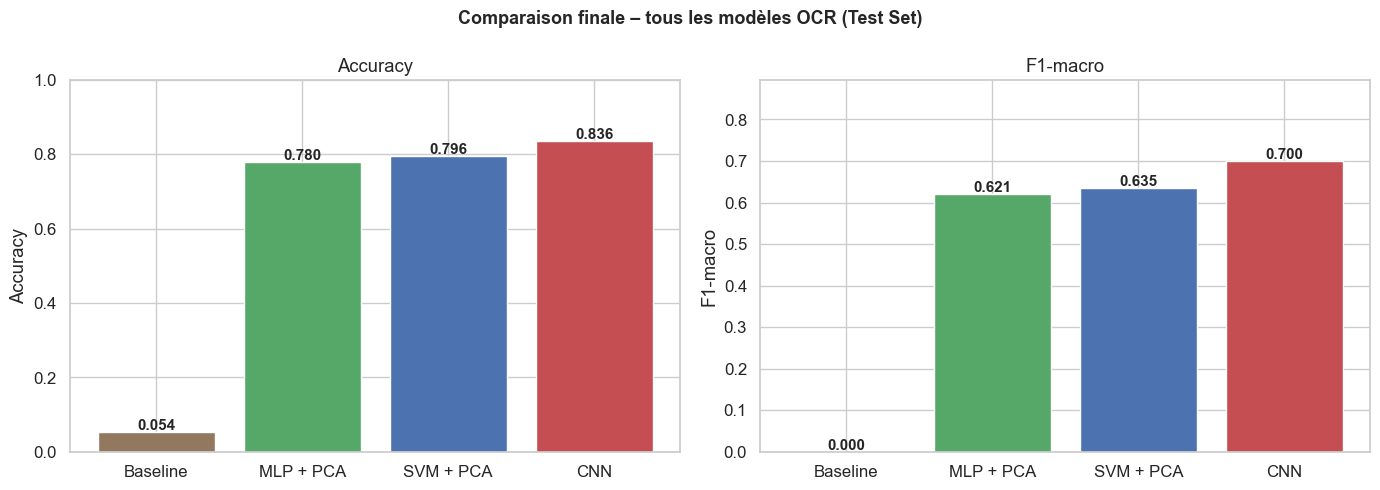

In [20]:
# --- Comparaison finale tous modèles OCR (mise à jour avec SVM et CNN) ---
_svm_acc = svm_acc if 'svm_acc' in globals() else 0
_svm_f1  = svm_f1  if 'svm_f1'  in globals() else 0
_cnn_acc = (cnn_acc if 'cnn_acc' in globals() and cnn_acc is not None else 0)
_cnn_f1  = (cnn_f1  if 'cnn_f1'  in globals() and cnn_f1  is not None else 0)

ocr_names_all = ['Baseline', 'MLP + PCA', 'SVM + PCA', 'CNN']
ocr_accs_all  = [baseline_ocr_acc, mlp_acc, _svm_acc, _cnn_acc]
ocr_f1s_all   = [0.0,              mlp_f1,  _svm_f1,  _cnn_f1]
cols_ocr = [PALETTE[5], PALETTE[2], PALETTE[0], PALETTE[3]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison finale – tous les modèles OCR (Test Set)', fontsize=13, fontweight='bold')

for ax, (vals, title) in zip(axes, [(ocr_accs_all, 'Accuracy'), (ocr_f1s_all, 'F1-macro')]):
    bars = ax.bar(ocr_names_all, vals, color=cols_ocr)
    ax.set_ylim(0, min(1.0, max(vals) * 1.25 + 0.02))
    ax.set_ylabel(title); ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()


### Analyse approfondie — Matrice de confusion et erreurs par classe

Au-delà des métriques globales, il est important d'identifier **quels caractères** sont mal reconnus et **avec quoi** ils sont confondus.

- **Matrice de confusion** : grille 62×62 où la cellule (i, j) = nombre d'exemples de la classe *i* prédits comme classe *j*. La diagonale = prédictions correctes.
- **Top paires de confusion** : paires de caractères visuellement proches qui génèrent le plus d'erreurs (ex. `O`/`0`, `l`/`1`/`I`, `S`/`5`).
- **Accuracy par classe** : certaines classes sont intrinsèquement plus difficiles en raison de leur similarité visuelle ou d'un nombre d'exemples plus faible.

Meilleur modèle sélectionné : CNN (Accuracy = 0.8355)


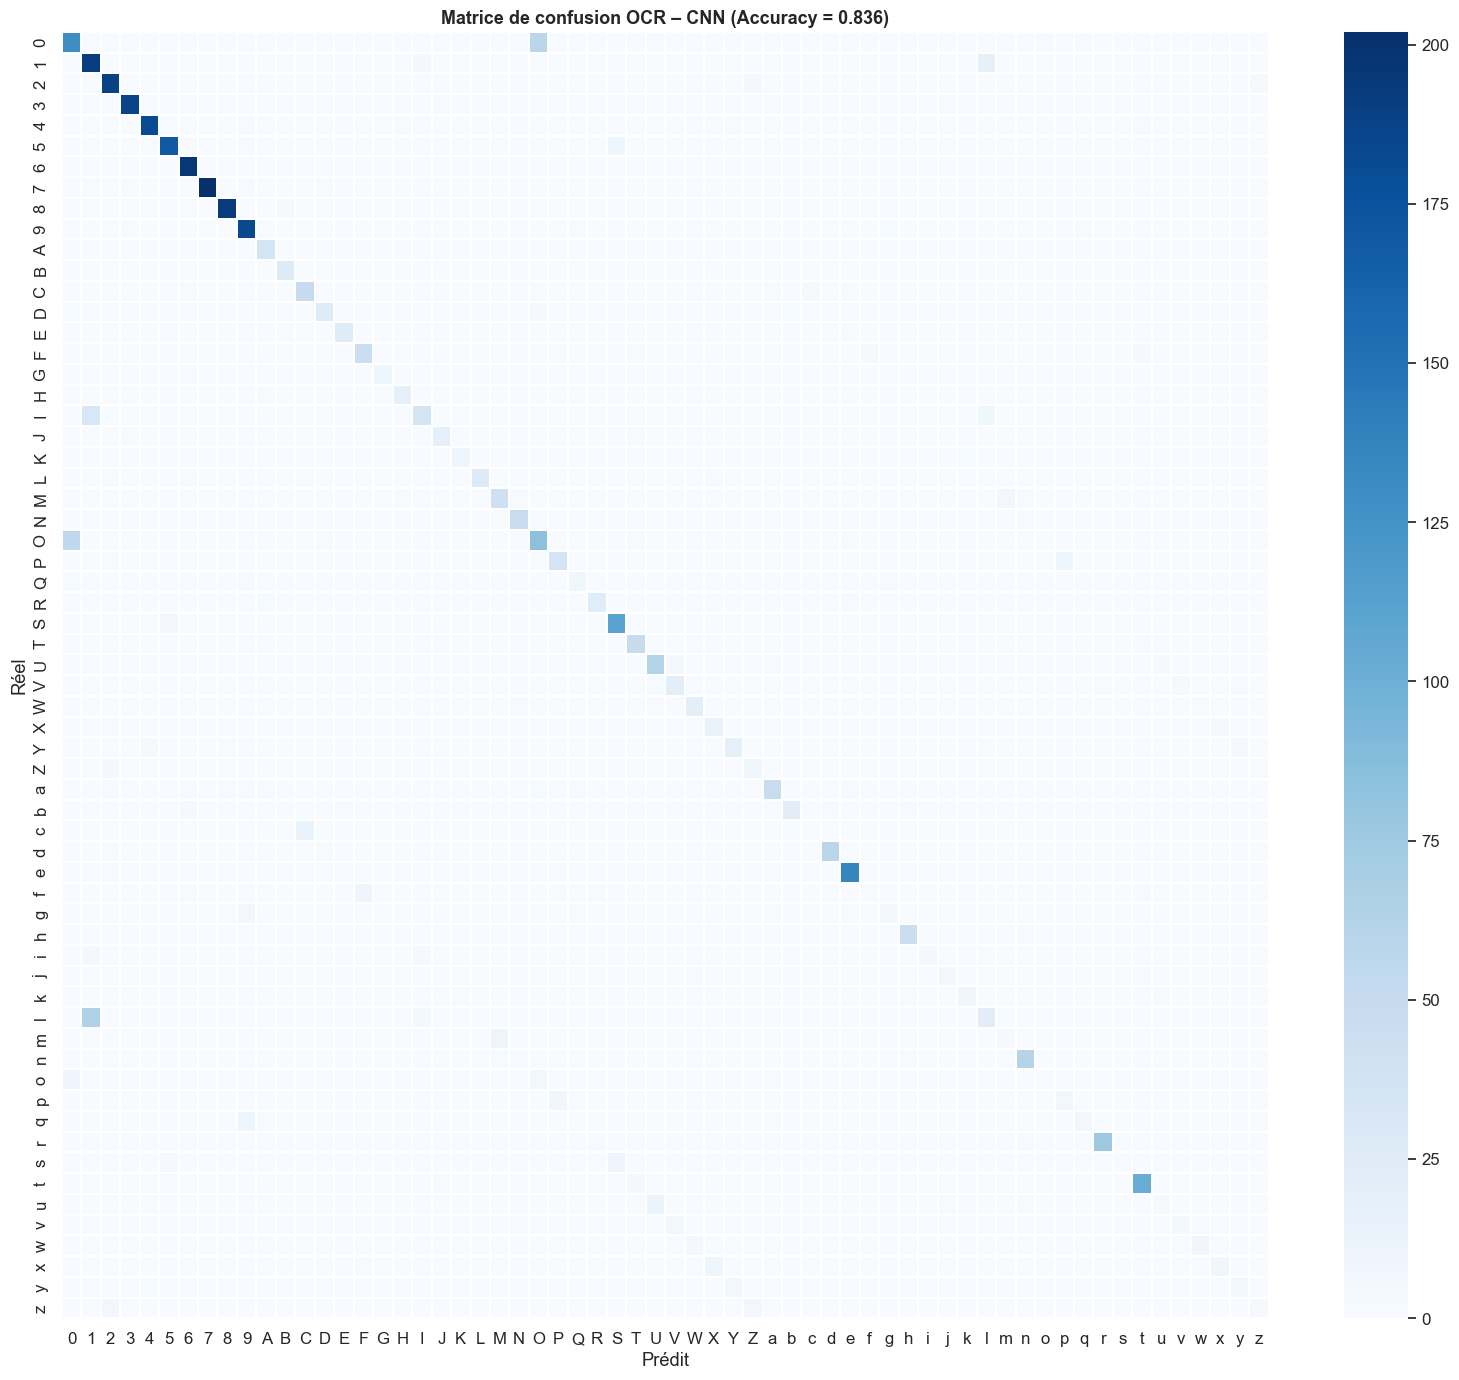


=== Top 15 paires de confusion (CNN) ===

Réel Prédit  Nb
   l      1  65
   0      O  59
   O      0  55
   I      1  32
   1      l  18
   c      C  14
   u      U  12
   s      S  11
   m      M  11
   f      F  10
   o      0  10
   q      9  10
   x      X  10
   5      S   9
   P      p   9


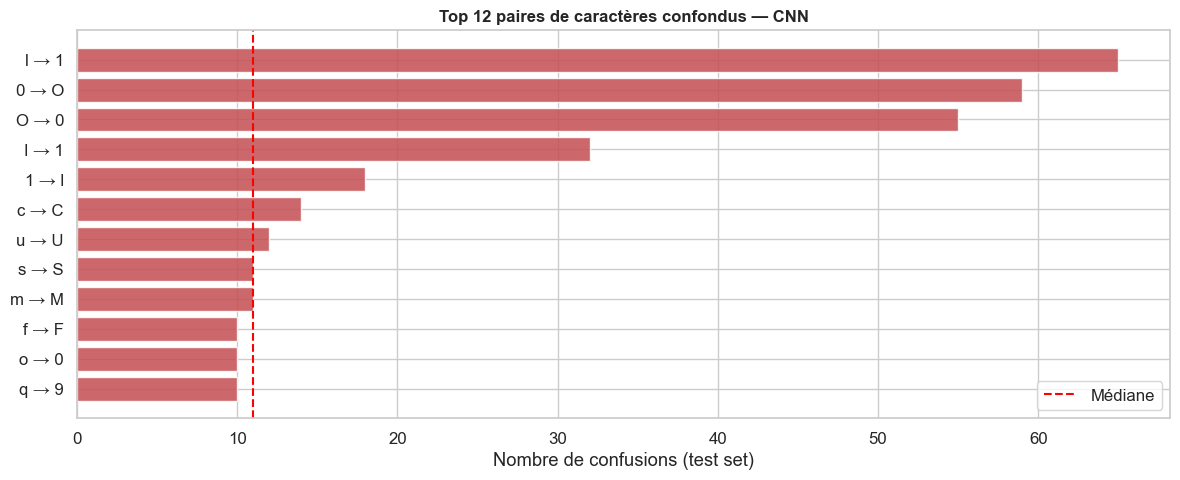


=== Exemples visuels de confusions OCR ===


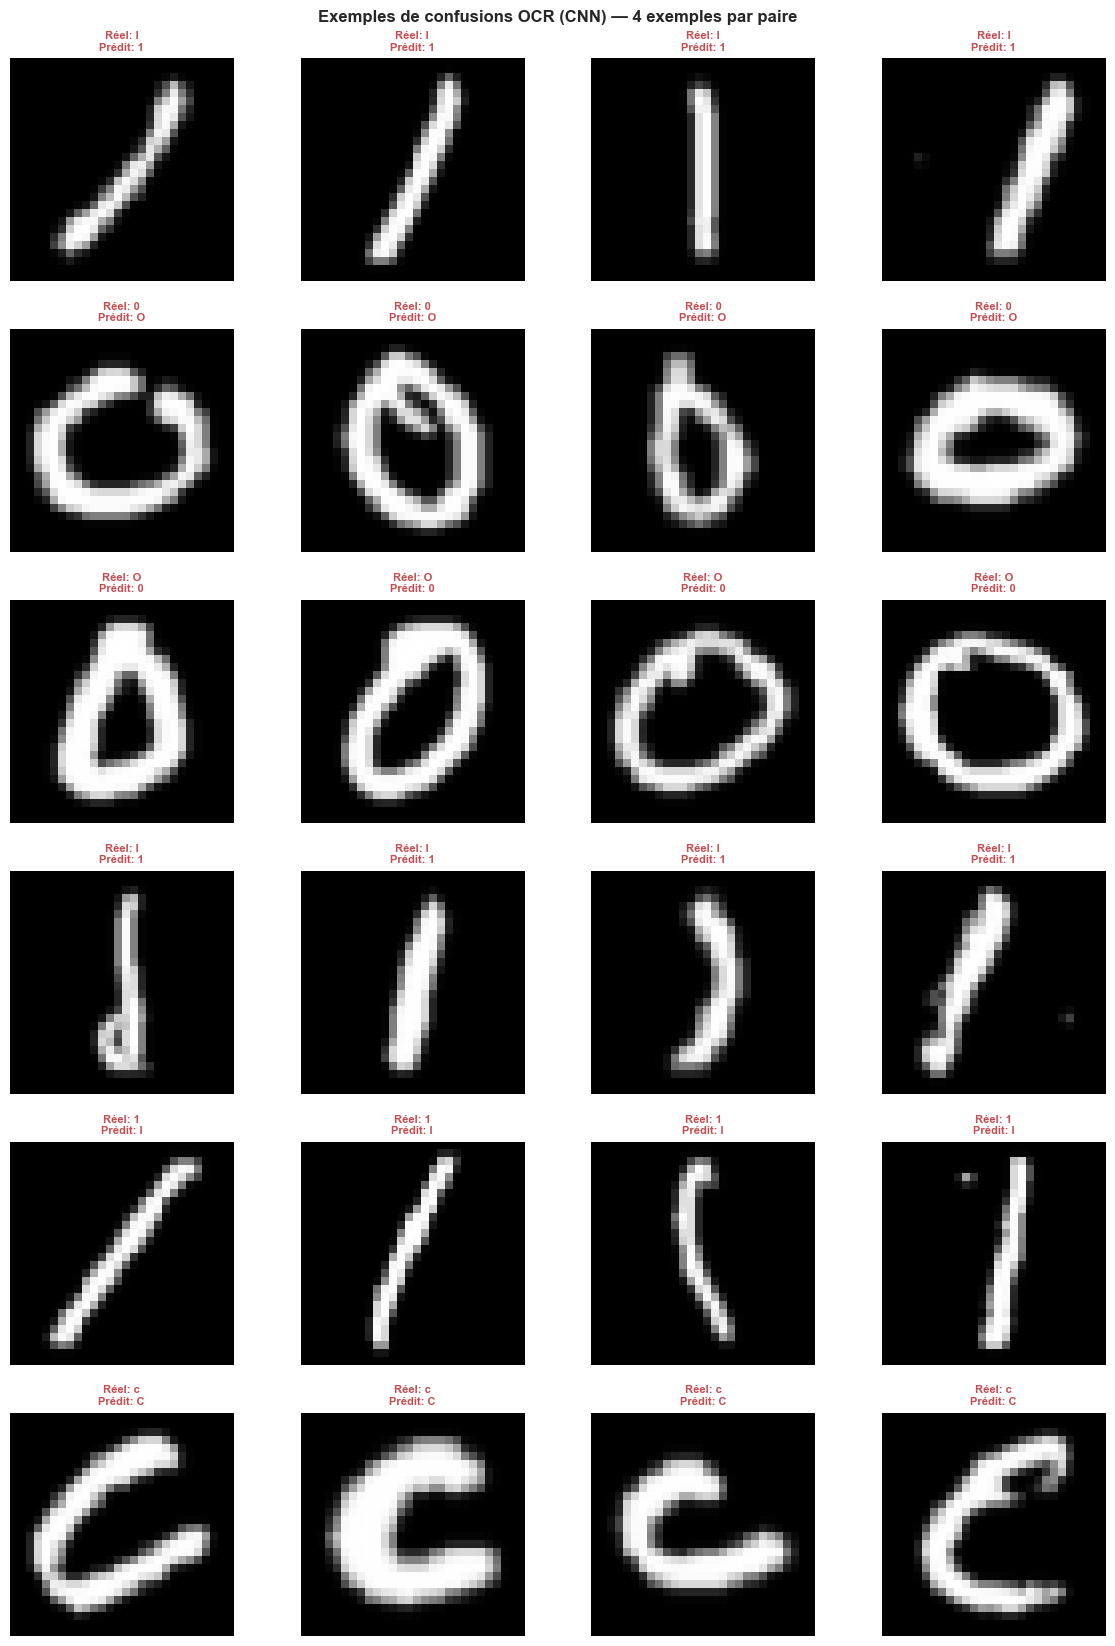

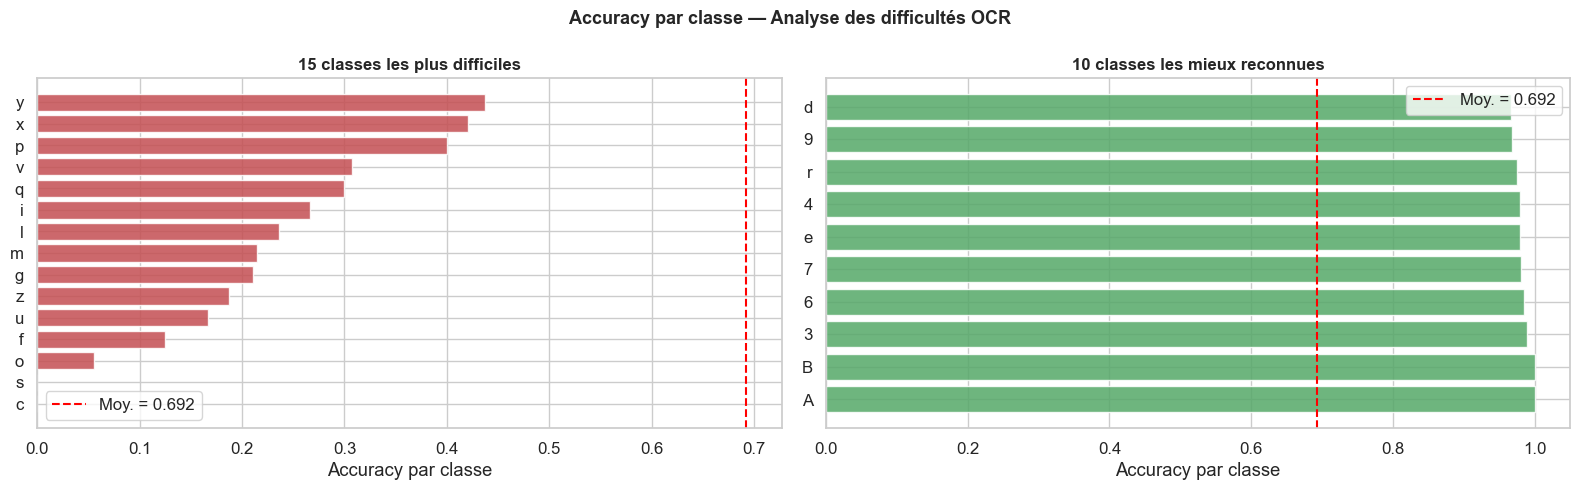


Classes les plus difficiles : ['c', 's', 'o', 'f', 'u']

Analyse des confusions typiques :
  • O/0 : similitude visuelle quasi-totale en écriture manuscrite
  • l/1/I : traits verticaux minces, difficiles à différencier
  • rn/m : combinaison de traits horizontaux similaires
  • S/5, B/8 : formes courbes proches selon le scripteur

Ces confusions sont inhérentes aux similarités visuelles des caractères
manuscrits et constituent une limite fondamentale des approches pixel-based.
Un post-traitement contextuel (correction orthographique) réduirait ces erreurs.

=== Discussion critique — Partie 2 : OCR ===

Performances obtenues (test set, 4,000 exemples) :
  MLP + PCA   : Accuracy = 0.7798  |  F1-macro = 0.6213
  SVM + PCA   : Accuracy = 0.7960  |  F1-macro = 0.6345
  CNN         : Accuracy = 0.8355  |  F1-macro = 0.7005
  Baseline    : Accuracy = 0.0542  |  (classe majoritaire)

Limitations :
  • Taille du sous-échantillon (20k/698k) : sous-utilisation du dataset.
    Entraîner sur le d

In [21]:

# ============================================================
# 2.4 Analyse détaillée de la matrice de confusion OCR
# ============================================================

# ── Vérification des prérequis ────────────────────────────────
_required = ['mlp_pred', 'mlp_acc', 'mlp_f1',
             'baseline_ocr_acc', 'y_te', 'X_te', 'char_labels', 'unique']
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        f"Variables manquantes — exécutez d'abord les cellules MLP (2.3a) "
        f"et pré-traitement : {_missing}"
    )

# ── Sélection du meilleur modèle (priorité : CNN > SVM > MLP) ─
svm_available = 'svm_acc' in globals() and 'svm_pred' in globals()
cnn_available = ('cnn_acc' in globals() and 'cnn_pred' in globals()
                 and cnn_acc is not None)

if cnn_available and cnn_acc >= mlp_acc and (not svm_available or cnn_acc >= svm_acc):
    best_ocr_pred, best_ocr_name, best_ocr_acc_val = cnn_pred, 'CNN', cnn_acc
elif svm_available and svm_acc > mlp_acc:
    best_ocr_pred, best_ocr_name, best_ocr_acc_val = svm_pred, 'SVM', svm_acc
else:
    best_ocr_pred, best_ocr_name, best_ocr_acc_val = mlp_pred, 'MLP', mlp_acc

print(f'Meilleur modèle sélectionné : {best_ocr_name} (Accuracy = {best_ocr_acc_val:.4f})')

# ── Matrice de confusion complète ────────────────────────────
cm = confusion_matrix(y_te, best_ocr_pred)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
            xticklabels=char_labels, yticklabels=char_labels, linewidths=0.1)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion OCR – {best_ocr_name} (Accuracy = {best_ocr_acc_val:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Top paires de confusion ───────────────────────────────────
print(f'\n=== Top 15 paires de confusion ({best_ocr_name}) ===\n')
confusions = []
for i, real_c in enumerate(char_labels):
    for j, pred_c in enumerate(char_labels):
        if i != j and cm[i, j] > 0:
            confusions.append({'Réel': real_c, 'Prédit': pred_c, 'Nb': cm[i, j]})

conf_df = pd.DataFrame(confusions).sort_values('Nb', ascending=False).head(15)
print(conf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
labels_conf = [f"{r['Réel']} → {r['Prédit']}" for _, r in conf_df.head(12).iterrows()]
ax.barh(labels_conf[::-1], conf_df['Nb'].head(12).values[::-1], color=PALETTE[3], alpha=0.85)
ax.set_xlabel('Nombre de confusions (test set)')
ax.set_title(f'Top 12 paires de caractères confondus — {best_ocr_name}',
             fontsize=12, fontweight='bold')
ax.axvline(conf_df['Nb'].median(), color='red', linestyle='--', label='Médiane')
ax.legend()
plt.tight_layout(); plt.show()

# ── Exemples visuels des cas mal classifiés ───────────────────
print('\n=== Exemples visuels de confusions OCR ===')
top_pairs = [(r['Réel'], r['Prédit']) for _, r in conf_df.head(8).iterrows()]
valid_pairs = []
for real_c, pred_c in top_pairs:
    ri = [i for i, c in enumerate(char_labels) if c == real_c]
    pi = [i for i, c in enumerate(char_labels) if c == pred_c]
    if ri and pi:
        mask = (y_te == unique[ri[0]]) & (best_ocr_pred == unique[pi[0]])
        if mask.sum() > 0:
            valid_pairs.append((real_c, pred_c, np.where(mask)[0]))

if valid_pairs:
    n_rows = min(len(valid_pairs), 6)
    fig, axes_grid = plt.subplots(n_rows, 4, figsize=(12, 2.8 * n_rows))
    if n_rows == 1:
        axes_grid = axes_grid[np.newaxis, :]
    fig.suptitle(f'Exemples de confusions OCR ({best_ocr_name}) — 4 exemples par paire',
                 fontsize=12, fontweight='bold')
    for row_idx, (real_c, pred_c, confused_indices) in enumerate(valid_pairs[:n_rows]):
        for col_idx in range(4):
            ax = axes_grid[row_idx, col_idx]
            if col_idx < len(confused_indices):
                img_idx = confused_indices[col_idx]
                ax.imshow(X_te[img_idx].reshape(28, 28), cmap='gray')
                ax.set_title(f'Réel: {real_c}\nPrédit: {pred_c}',
                             fontsize=8, color='#C44E52', fontweight='bold')
            ax.axis('off')
    plt.tight_layout(); plt.show()

# ── Accuracy par classe ───────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_cls = pd.Series(per_class_acc, index=char_labels).sort_values().head(15)
best_cls  = pd.Series(per_class_acc, index=char_labels).sort_values(ascending=False).head(10)
mean_acc  = per_class_acc.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(worst_cls.index, worst_cls.values, color=PALETTE[3], alpha=0.85)
axes[0].axvline(mean_acc, color='red', linestyle='--', label=f'Moy. = {mean_acc:.3f}')
axes[0].set_title('15 classes les plus difficiles', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy par classe'); axes[0].legend()

axes[1].barh(best_cls.index, best_cls.values, color=PALETTE[2], alpha=0.85)
axes[1].axvline(mean_acc, color='red', linestyle='--', label=f'Moy. = {mean_acc:.3f}')
axes[1].set_title('10 classes les mieux reconnues', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Accuracy par classe'); axes[1].legend()

plt.suptitle('Accuracy par classe — Analyse des difficultés OCR', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nClasses les plus difficiles : {list(worst_cls.index[:5])}')
print('\nAnalyse des confusions typiques :')
print('  • O/0 : similitude visuelle quasi-totale en écriture manuscrite')
print('  • l/1/I : traits verticaux minces, difficiles à différencier')
print('  • rn/m : combinaison de traits horizontaux similaires')
print('  • S/5, B/8 : formes courbes proches selon le scripteur')
print('\nCes confusions sont inhérentes aux similarités visuelles des caractères')
print('manuscrits et constituent une limite fondamentale des approches pixel-based.')
print('Un post-traitement contextuel (correction orthographique) réduirait ces erreurs.')

# ── Discussion critique OCR ────────────────────────────────────
print('\n=== Discussion critique — Partie 2 : OCR ===')
svm_line = (f'  SVM + PCA   : Accuracy = {svm_acc:.4f}  |  F1-macro = {svm_f1:.4f}'
            if svm_available else '  SVM + PCA   : non exécuté')
cnn_line = (f'  CNN         : Accuracy = {cnn_acc:.4f}  |  F1-macro = {cnn_f1:.4f}'
            if cnn_available else '  CNN         : non exécuté')
print(f"""
Performances obtenues (test set, {len(y_te):,} exemples) :
  MLP + PCA   : Accuracy = {mlp_acc:.4f}  |  F1-macro = {mlp_f1:.4f}
{svm_line}
{cnn_line}
  Baseline    : Accuracy = {baseline_ocr_acc:.4f}  |  (classe majoritaire)

Limitations :
  • Taille du sous-échantillon (20k/698k) : sous-utilisation du dataset.
    Entraîner sur le dataset complet améliorerait significativement les performances.
  • PCA (64 dims) : perte d'information spatiale. Un CNN (sans PCA) exploite
    la structure 2D et devrait surpasser MLP et SVM.
  • Absence de contexte linguistique : une lettre isolée est plus difficile
    à reconnaître qu'un mot complet (le contexte réduit l'ambiguïté).
""")


## 2.5 Tableau de précision / rappel / F1 par classe

Pour chaque classe, trois métriques complémentaires sont calculées :

| Métrique | Formule | Signification |
|----------|---------|---------------|
| **Précision** | VP / (VP + FP) | Parmi toutes les prédictions de cette classe, combien sont correctes ? |
| **Rappel** (*Recall*) | VP / (VP + FN) | Parmi tous les vrais exemples de cette classe, combien ont été détectés ? |
| **F1-score** | 2 × (P × R) / (P + R) | Moyenne harmonique précision/rappel — pénalise les déséquilibres |

> **VP** = Vrais Positifs · **FP** = Faux Positifs · **FN** = Faux Négatifs

Un F1 faible peut indiquer : mauvais rappel (classe rarement détectée) ou mauvaise précision (classe souvent prédite à tort pour d'autres caractères).

=== Rapport précision / rappel / F1 par classe — CNN ===

   precision  recall    f1  support
3      0.984   0.989 0.987  189.000
7      0.981   0.981 0.981  206.000
d      0.983   0.967 0.975   60.000
6      0.951   0.985 0.968  199.000
8      0.970   0.965 0.967  200.000
e      0.951   0.978 0.965  139.000
4      0.948   0.978 0.963  185.000
r      0.938   0.974 0.956   78.000
N      0.925   0.961 0.942   51.000
2      0.913   0.964 0.938  196.000
A      0.881   1.000 0.937   37.000
t      0.927   0.936 0.932  109.000
5      0.929   0.934 0.931  181.000
B      0.867   1.000 0.929   26.000
9      0.888   0.968 0.927  189.000
n      0.910   0.938 0.924   65.000
h      0.939   0.902 0.920   51.000
T      0.877   0.943 0.909   53.000
J      0.905   0.905 0.905   21.000
R      0.920   0.885 0.902   26.000
H      0.850   0.944 0.895   18.000
E      0.926   0.833 0.877   30.000
a      0.907   0.845 0.875   58.000
S      0.824   0.926 0.872  121.000
G      1.000   0.769 0.870   13.000
L     

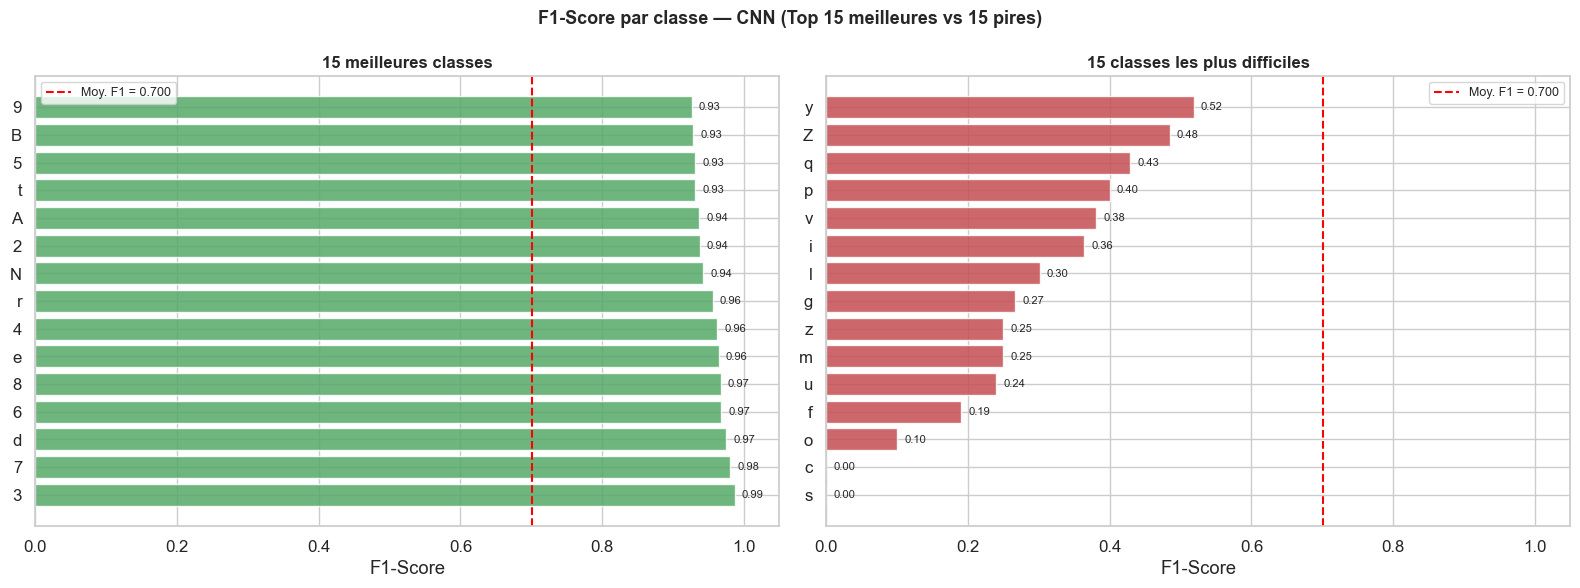

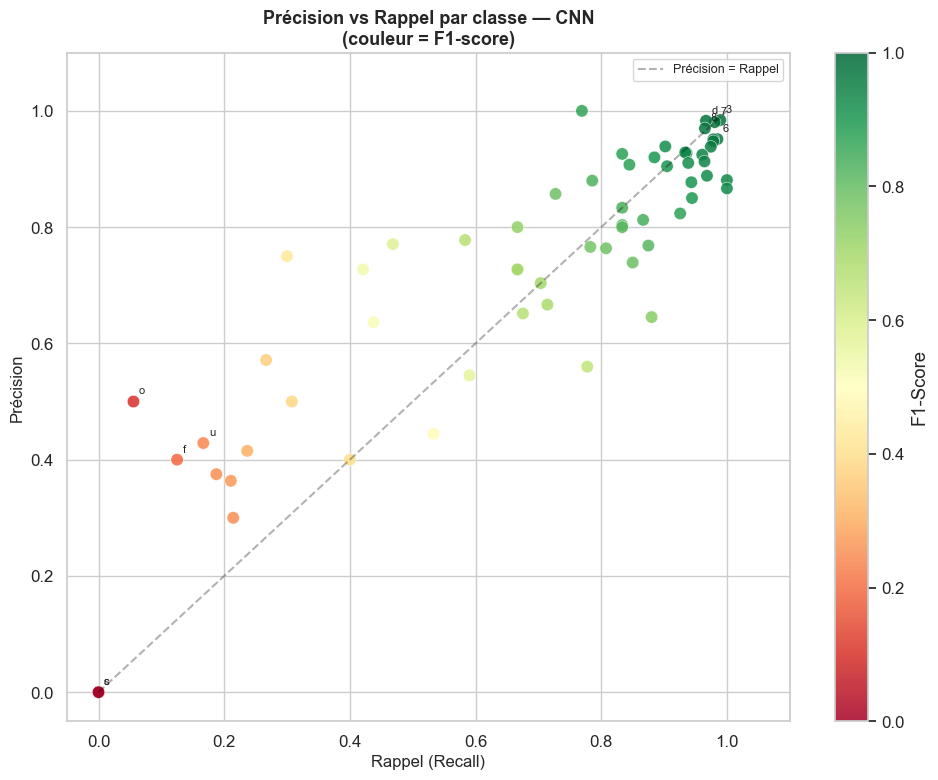

In [22]:
# ============================================================
# 2.5  Précision / Rappel / F1 par classe — meilleur modèle
# ============================================================

# ── Rapport complet sklearn ───────────────────────────────────
report_dict = classification_report(
    y_te, best_ocr_pred,
    labels=unique, target_names=char_labels,
    output_dict=True, zero_division=0
)

# DataFrame par classe (hors lignes macro/weighted/accuracy)
df_report = pd.DataFrame(report_dict).T
df_report = df_report.loc[char_labels].copy()
df_report = df_report.rename(columns={'f1-score': 'f1'})
df_report[['precision', 'recall', 'f1', 'support']] = \
    df_report[['precision', 'recall', 'f1', 'support']].apply(pd.to_numeric)
df_report = df_report.sort_values('f1', ascending=False)

print(f'=== Rapport précision / rappel / F1 par classe — {best_ocr_name} ===\n')
print(df_report[['precision', 'recall', 'f1', 'support']].to_string(float_format='{:.3f}'.format))
print(f'\nF1-macro moyen : {df_report["f1"].mean():.4f}')

# ── Graphe 1 : Top 15 meilleures / pires classes (F1) ─────────
top15  = df_report.head(15)
bot15  = df_report.tail(15).sort_values('f1')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'F1-Score par classe — {best_ocr_name} (Top 15 meilleures vs 15 pires)',
             fontsize=13, fontweight='bold')

for ax, sub, color, title in [
    (axes[0], top15, PALETTE[2], '15 meilleures classes'),
    (axes[1], bot15, PALETTE[3], '15 classes les plus difficiles'),
]:
    bars = ax.barh(sub.index, sub['f1'], color=color, alpha=0.85)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('F1-Score')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axvline(df_report['f1'].mean(), color='red', linestyle='--',
               label=f'Moy. F1 = {df_report["f1"].mean():.3f}')
    ax.legend(fontsize=9)
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(row['f1'] + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{row["f1"]:.2f}', va='center', fontsize=8)

plt.tight_layout(); plt.show()

# ── Graphe 2 : Précision vs Rappel, coloré par F1 ─────────────
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df_report['recall'], df_report['precision'],
    c=df_report['f1'], cmap='RdYlGn', s=80, alpha=0.85,
    vmin=0, vmax=1, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='F1-Score')

# Annoter les points extrêmes (5 meilleurs et 5 pires F1)
for cls, row in pd.concat([df_report.head(5), df_report.tail(5)]).iterrows():
    ax.annotate(cls, (row['recall'], row['precision']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Rappel (Recall)', fontsize=12)
ax.set_ylabel('Précision', fontsize=12)
ax.set_title(f'Précision vs Rappel par classe — {best_ocr_name}\n(couleur = F1-score)',
             fontsize=13, fontweight='bold')
ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.1)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Précision = Rappel')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
